#Proyek Analisis Data: HabitSense
- ID Tim Capstone Project: CC26-PSU218
- Tema Capstone: Healthy Lives and Well Being
- Nama/Judul Proyek: HabitSense

##Pertanyaan Bisnis:
- Pertanyaan 1: Bagaimana hubungan antara durasi tidur, tingkat stres, dan jumlah langkah harian terhadap kategori BMI pengguna selama program kesehatan berlangsung?
- Pertanyaan 2: Apakah pengguna dengan goal type berbeda memiliki kebutuhan target kalori harian yang berbeda selama periode program kesehatan?
- Pertanyaan 3: Bagaimana pengaruh durasi program kesehatan terhadap perubahan target berat badan pengguna selama program berlangsung?

##Import Packages/Library

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

##Data Wrangling

###Gathering Data

In [51]:
df = pd.read_csv("habitsense_dataset.csv")
df.head()

,Person_ID,Gender,Age,Occupation,Height_cm,Weight_kg,Target_Weight_kg,BMI_Value,BMI_Category,Goal_Type,Program_Duration_Days,Target_Calorie_Day,Sleep_Duration,Stress_Level,Daily_Steps,Sleep_Disorder
0,8576,Male,24,Doctor,161.4,86.2,71.8,33.1,Obese,Cutting,204,1749.0,5.9,2.0,2180.0,NaN
1,3743,Female,23,Data Analyst,173.4,63.6,56.2,21.2,Normal,Cutting,39,1201.0,7.2,2.0,12918.0,NaN
2,6232,Male,41,Accountant,176.3,61.2,61.2,19.7,Normal,Maintain,279,1952.0,6.7,4.0,10673.0,NaN
3,5724,Male,45,Software Engineer,167.1,NaN,51.1,22.8,Normal,Cutting,130,1188.0,9.1,3.0,13775.0,NaN
4,8988,Male,50,Nurse,190.7,74.5,66.8,20.5,Normal,Cutting,228,1927.0,8.2,4.0,4989.0,Sleep Apnea


###Assesing Data

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Person_ID              10200 non-null  int64  
 1   Gender                 10200 non-null  object 
 2   Age                    10200 non-null  int64  
 3   Occupation             10200 non-null  object 
 4   Height_cm              9996 non-null   float64
 5   Weight_kg              9996 non-null   float64
 6   Target_Weight_kg       9996 non-null   float64
 7   BMI_Value              10200 non-null  float64
 8   BMI_Category           10200 non-null  object 
 9   Goal_Type              10200 non-null  object 
 10  Program_Duration_Days  10200 non-null  int64  
 11  Target_Calorie_Day     10200 non-null  float64
 12  Sleep_Duration         9997 non-null   float64
 13  Stress_Level           9996 non-null   float64
 14  Daily_Steps            9997 non-null   float64
 15  Sl

In [53]:
categorical_cols = [
    'Gender',
    'BMI_Category',
    'Goal_Type'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Male      5131
Female    5069
Name: count, dtype: int64

BMI_Category
BMI_Category
Normal         3116
Obese          3085
Overweight     2486
Underweight    1513
Name: count, dtype: int64

Goal_Type
Goal_Type
Cutting     7097
Bulking     1594
Maintain    1509
Name: count, dtype: int64


In [54]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  152


In [55]:
df.describe()

,Person_ID,Age,Height_cm,Weight_kg,Target_Weight_kg,BMI_Value,Program_Duration_Days,Target_Calorie_Day,Sleep_Duration,Stress_Level,Daily_Steps
count,10200.000000,10200.000000,9996.000000,9996.000000,9996.000000,10200.000000,10200.000000,10200.000000,9997.000000,9996.000000,9997.000000
mean,4997.155882,38.597157,170.040536,74.792987,70.145918,26.249725,197.549510,1811.848627,7.030419,5.004002,8246.365510
std,2887.039983,12.790366,10.049977,20.770315,18.238355,7.772667,96.768394,497.022963,1.487637,2.581999,5831.695878
min,1.000000,18.000000,128.400000,-45.000000,-6.500000,2.000000,30.000000,1150.000000,2.100000,1.000000,1000.000000
25%,2500.750000,28.000000,163.100000,61.400000,58.900000,20.900000,114.000000,1539.000000,6.200000,3.000000,4520.000000
50%,4995.500000,38.000000,170.100000,75.100000,70.300000,25.900000,198.000000,1810.000000,7.000000,5.000000,8131.000000
75%,7500.250000,49.000000,176.900000,88.500000,81.600000,31.200000,281.000000,2050.000000,7.800000,7.000000,11570.000000
max,10000.000000,150.000000,208.100000,144.400000,137.100000,63.800000,365.000000,9000.000000,25.000000,9.000000,100000.000000


In [56]:
df.isna().sum()

,0
Person_ID,0
Gender,0
Age,0
Occupation,0
Height_cm,204
Weight_kg,204
Target_Weight_kg,204
BMI_Value,0
BMI_Category,0
Goal_Type,0


###Cleaning Data

In [57]:
df.duplicated().sum()

np.int64(152)

In [58]:
df.drop_duplicates(inplace=True)

In [59]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [60]:
df.isna().sum()

,0
Person_ID,0
Gender,0
Age,0
Occupation,0
Height_cm,204
Weight_kg,204
Target_Weight_kg,204
BMI_Value,0
BMI_Category,0
Goal_Type,0


In [61]:
numeric_cols = [
    'Age',
    'Height_cm',
    'Weight_kg',
    'Target_Weight_kg',
    'BMI_Value',
    'Program_Duration_Days',
    'Target_Calorie_Day',
    'Sleep_Duration',
    'Stress_Level',
    'Daily_Steps'
]

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1309/766570791.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [62]:
categorical_cols = [
    'Gender',
    'Occupation',
    'BMI_Category',
    'Goal_Type',
    'Sleep_Disorder'
]

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1309/3499248153.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [63]:
df.isna().sum()

,0
Person_ID,0
Gender,0
Age,0
Occupation,0
Height_cm,0
Weight_kg,0
Target_Weight_kg,0
BMI_Value,0
BMI_Category,0
Goal_Type,0


**Insight**

1. Pada tahap cleaning, ditemukan sebanyak 152 data duplikat, kemudian data tersebut dihapus agar tidak menyebabkan penghitungan analisis menjadi bias.

2. Setelah proses penghapusan duplikasi dilakukan, jumlah data duplikat menjadi 0, sehingga setiap baris data merepresentasikan satu observasi yang unik.

3. Missing values pada kolom numerik seperti Height_cm, Weight_kg, Target_Weight_kg, Sleep_Duration, Stress_Level, dan Daily_Steps ditangani menggunakan nilai median karena lebih tahan terhadap pengaruh outlier.

4. Missing values pada kolom kategorikal seperti Gender, Occupation, BMI_Category, Goal_Type, dan Sleep_Disorder ditangani menggunakan modus, yaitu nilai yang paling sering muncul pada masing-masing kolom.

5. Setelah cleaning, dataset menjadi lebih lengkap, bebas duplikasi, dan lebih siap digunakan untuk tahap exploratory data analysis tanpa kehilangan banyak data penting.

##Exploratory Data Analysis

In [64]:
df.sample(5)

,Person_ID,Gender,Age,Occupation,Height_cm,Weight_kg,Target_Weight_kg,BMI_Value,BMI_Category,Goal_Type,Program_Duration_Days,Target_Calorie_Day,Sleep_Duration,Stress_Level,Daily_Steps,Sleep_Disorder
1032,1122,Female,40,Sales Representative,172.9,88.4,77.7,29.6,Overweight,Cutting,44,1160.0,7.7,3.0,8579.0,Insomnia
7052,914,Female,37,Designer,164.2,71.1,67.3,26.4,Overweight,Cutting,181,1615.0,6.5,2.0,11960.0,Insomnia
4759,4349,Female,21,Software Engineer,175.9,79.7,72.9,25.8,Overweight,Cutting,47,1219.0,7.8,8.0,14182.0,Sleep Apnea
8108,5979,Female,45,Data Analyst,160.3,97.0,92.5,37.7,Obese,Cutting,283,1922.0,7.7,6.0,12489.0,Sleep Apnea
3523,8361,Female,25,Sales Representative,177.2,106.3,100.5,33.9,Obese,Cutting,162,2151.0,6.7,2.0,11365.0,Sleep Apnea


In [65]:
df.describe(include="all")

,Person_ID,Gender,Age,Occupation,Height_cm,Weight_kg,Target_Weight_kg,BMI_Value,BMI_Category,Goal_Type,Program_Duration_Days,Target_Calorie_Day,Sleep_Duration,Stress_Level,Daily_Steps,Sleep_Disorder
count,10048.000000,10048,10048.000000,10048,10048.000000,10048.000000,10048.000000,10048.000000,10048,10048,10048.000000,10048.000000,10048.000000,10048.000000,10048.000000,10048
unique,NaN,2,NaN,10,NaN,NaN,NaN,NaN,4,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Male,NaN,Teacher,NaN,NaN,NaN,NaN,Normal,Cutting,NaN,NaN,NaN,NaN,NaN,Sleep Apnea
freq,NaN,5052,NaN,1079,NaN,NaN,NaN,NaN,3063,6988,NaN,NaN,NaN,NaN,NaN,6756
mean,4998.750995,NaN,38.622313,NaN,170.028583,74.798706,70.159106,26.254916,NaN,NaN,197.479697,1812.261843,7.031708,5.007365,8244.402070,NaN
std,2888.095834,NaN,12.793596,NaN,9.959012,20.599384,18.082918,7.784175,NaN,NaN,96.722470,498.843421,1.476777,2.554501,5794.914353,NaN
min,1.000000,NaN,18.000000,NaN,128.400000,-45.000000,-6.500000,2.000000,NaN,NaN,30.000000,1150.000000,2.100000,1.000000,1000.000000,NaN
25%,2497.750000,NaN,28.000000,NaN,163.200000,61.800000,59.200000,20.900000,NaN,NaN,114.000000,1539.000000,6.200000,3.000000,4581.750000,NaN
50%,5001.500000,NaN,38.000000,NaN,170.000000,75.100000,70.300000,25.900000,NaN,NaN,198.000000,1809.500000,7.000000,5.000000,8132.000000,NaN
75%,7500.250000,NaN,49.000000,NaN,176.700000,88.200000,81.300000,31.200000,NaN,NaN,281.000000,2049.250000,7.800000,7.000000,11506.250000,NaN


In [66]:
print("Person ID is unique:", df.Person_ID.is_unique)

Person ID is unique: False


In [67]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  4


In [68]:
df.drop_duplicates(inplace=True)

print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [69]:
df['Person_ID'] = range(1, len(df) + 1)

In [70]:
print("Person ID is unique:", df.Person_ID.is_unique)

Person ID is unique: True


In [71]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\n===== KOLOM NUMERIK =====")
print(list(numeric_cols))

print("\n===== KOLOM KATEGORIKAL =====")
print(list(categorical_cols))



===== KOLOM NUMERIK =====
['Person_ID', 'Age', 'Height_cm', 'Weight_kg', 'Target_Weight_kg', 'BMI_Value', 'Program_Duration_Days', 'Target_Calorie_Day', 'Sleep_Duration', 'Stress_Level', 'Daily_Steps']

===== KOLOM KATEGORIKAL =====
['Gender', 'Occupation', 'BMI_Category', 'Goal_Type', 'Sleep_Disorder']


In [72]:
correlation = df[numeric_cols].corr()

print(correlation)

                       Person_ID       Age  Height_cm  Weight_kg  \
Person_ID               1.000000  0.016783   0.009106  -0.017562   
Age                     0.016783  1.000000   0.010462  -0.003188   
Height_cm               0.009106  0.010462   1.000000  -0.015181   
Weight_kg              -0.017562 -0.003188  -0.015181   1.000000   
Target_Weight_kg       -0.021388 -0.006948   0.052962   0.898079   
BMI_Value              -0.018619 -0.004942  -0.406135   0.868727   
Program_Duration_Days  -0.013431  0.020402  -0.003274  -0.004568   
Target_Calorie_Day     -0.011593 -0.123144   0.257041   0.202506   
Sleep_Duration         -0.022712 -0.010105   0.003963  -0.009665   
Stress_Level            0.002343 -0.001279  -0.006325  -0.002202   
Daily_Steps             0.014168  0.006159   0.004208   0.003834   

                       Target_Weight_kg  BMI_Value  Program_Duration_Days  \
Person_ID                     -0.021388  -0.018619              -0.013431   
Age                          

In [73]:
for col in numeric_cols:

    if col != 'Person_ID':

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print(f"{col}: {len(outliers)} outlier")

Age: 14 outlier
Height_cm: 71 outlier
Weight_kg: 97 outlier
Target_Weight_kg: 215 outlier
BMI_Value: 112 outlier
Program_Duration_Days: 0 outlier
Target_Calorie_Day: 99 outlier
Sleep_Duration: 110 outlier
Stress_Level: 0 outlier
Daily_Steps: 21 outlier


In [74]:
for col in numeric_cols:

    if col != 'Person_ID':

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])

In [75]:
for col in numeric_cols:

    if col != 'Person_ID':

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print(f"{col}: {len(outliers)} outlier")

Age: 0 outlier
Height_cm: 0 outlier
Weight_kg: 0 outlier
Target_Weight_kg: 0 outlier
BMI_Value: 0 outlier
Program_Duration_Days: 0 outlier
Target_Calorie_Day: 0 outlier
Sleep_Duration: 0 outlier
Stress_Level: 0 outlier
Daily_Steps: 0 outlier


In [76]:
df['Weight_Change'] = (
    df['Target_Weight_kg'] - df['Weight_kg']
)

print(df['Weight_Change'].describe())

Q1 = df['Weight_Change'].quantile(0.25)
Q3 = df['Weight_Change'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

print("Lower Bound :", lower)
print("Upper Bound :", upper)

outliers = df[
    (df['Weight_Change'] < lower) |
    (df['Weight_Change'] > upper)
]

print("\nJumlah Outlier :", len(outliers))

print("\nContoh Outlier:")
print(
    outliers[
        [
            'Weight_kg',
            'Target_Weight_kg',
            'Weight_Change',
            'Program_Duration_Days',
            'Goal_Type'
        ]
    ].head()
)

df_clean = df[
    (df['Weight_Change'] >= lower) &
    (df['Weight_Change'] <= upper)
]

print("\nJumlah Data Sebelum :", len(df))
print("Jumlah Data Sesudah :", len(df_clean))

count    10044.000000
mean        -4.749119
std          7.669169
min        -54.300000
25%        -10.200000
50%         -5.500000
75%          0.000000
max         91.500000
Name: Weight_Change, dtype: float64
Q1 : -10.200000000000003
Q3 : 0.0
IQR : 10.200000000000003
Lower Bound : -25.500000000000007
Upper Bound : 15.300000000000004

Jumlah Outlier : 102

Contoh Outlier:
     Weight_kg  Target_Weight_kg  Weight_Change  Program_Duration_Days  \
107       75.1              48.9          -26.2                  122.0   
160       22.2             100.9           78.7                   53.0   
246       50.2              70.3           20.1                   91.0   
348       75.1              95.7           20.6                  103.0   
367       22.2              79.9           57.7                  312.0   

    Goal_Type  
107   Cutting  
160   Cutting  
246   Bulking  
348   Cutting  
367   Cutting  

Jumlah Data Sebelum : 10044
Jumlah Data Sesudah : 9942


**Insight**

1. Dataset awal memiliki 10.044 data setelah dilakukan pengecekan dan penghapusan sebanyak 4 data duplikat, sehingga seluruh data yang digunakan pada proses analisis menjadi lebih konsisten dan tidak terjadi pengulangan observasi.

2. Seluruh `Person_ID` berhasil dibuat unik, sehingga setiap baris data merepresentasikan satu pengguna yang berbeda dan tidak terdapat identitas pengguna yang sama di dalam dataset.

3. Hasil analisis korelasi menunjukkan bahwa `Weight_kg` memiliki hubungan sangat kuat dengan `Target_Weight_kg` sebesar 0.898, yang menandakan target berat badan pengguna sangat dipengaruhi oleh berat badan awal mereka.

4. Variabel `BMI_Value` memiliki korelasi tinggi terhadap `Weight_kg` sebesar 0.869, sehingga peningkatan berat badan cenderung diikuti dengan peningkatan nilai BMI pengguna.

5. Variabel `Target_Calorie_Day` memiliki korelasi positif terhadap `Program_Duration_Days` sebesar 0.197, yang menunjukkan bahwa program kesehatan dengan durasi lebih panjang cenderung memiliki kebutuhan target kalori yang lebih besar.

6. Ditemukan cukup banyak outlier pada beberapa variabel kesehatan, seperti `Target_Weight_kg` sebanyak 215 outlier, `BMI_Value` sebanyak 112 outlier, `Sleep_Duration` sebanyak 110 outlier, dan `Weight_kg` sebanyak 97 outlier, yang mengindikasikan adanya nilai ekstrem pada sebagian data pengguna.

7. Penanganan outlier dilakukan menggunakan metode IQR dan capping, sehingga seluruh variabel numerik berhasil dibersihkan hingga tidak terdapat outlier lagi pada dataset.

8. Analisis `Weight_Change` menunjukkan rata-rata perubahan target berat badan pengguna sebesar -4.75 kg, yang menandakan mayoritas pengguna mengikuti program kesehatan dengan tujuan menurunkan berat badan.

9. Nilai minimum perubahan berat badan mencapai -54.3 kg dan maksimum mencapai 91.5 kg, yang menunjukkan adanya beberapa target perubahan berat badan yang sangat ekstrem dan kurang realistis pada dataset.

10. Setelah proses pembersihan outlier pada variabel `Weight_Change`, jumlah data berkurang dari 10.044 menjadi 9.942 data, sehingga dataset akhir menjadi lebih stabil, representatif, dan siap digunakan untuk exploratory data analysis maupun pengembangan model machine learning.


##Visualization & Explanatory Analysis

###Pertanyaan 1: Bagaimana hubungan antara durasi tidur, tingkat stres, dan jumlah langkah harian terhadap kategori BMI pengguna selama program kesehatan berlangsung?

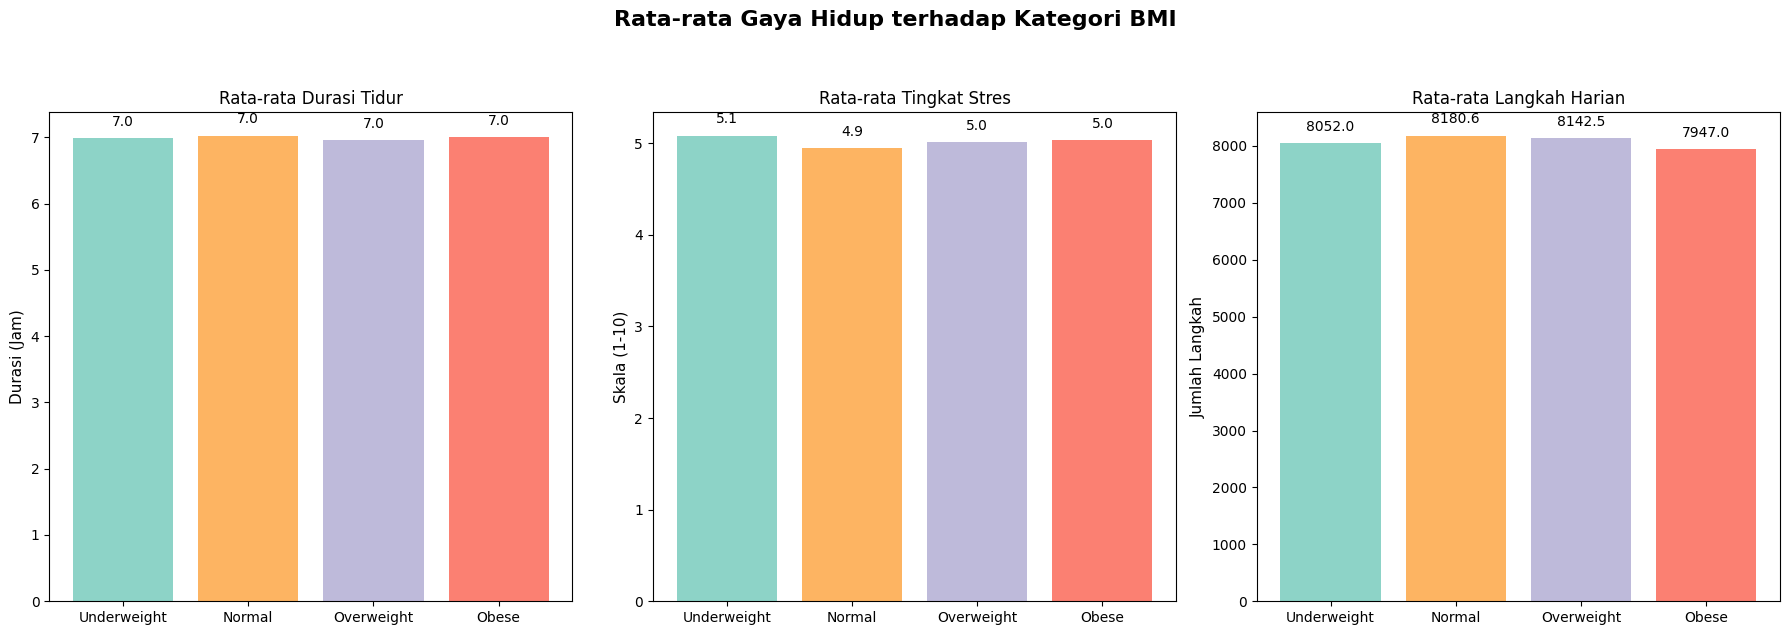

In [77]:


#Menghitung rata-rata berdasarkan Kategori BMI
bmi_analysis = (
    df.groupby('BMI_Category')[
        ['Sleep_Duration', 'Stress_Level', 'Daily_Steps']
    ]
    .mean()
)

#Mengurutkan Kategori BMI dari Kurus ke Gemuk
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
bmi_analysis = bmi_analysis.reindex(bmi_order)

my_colors = ['#8dd3c7', '#fdb462', '#bebada', '#fb8072']


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Rata-rata Gaya Hidup terhadap Kategori BMI', fontsize=16, fontweight='bold', y=1.05)

# Grafik Durasi Tidur
axes[0].bar(bmi_analysis.index, bmi_analysis['Sleep_Duration'], color=my_colors)
axes[0].set_title('Rata-rata Durasi Tidur', fontsize=12)
axes[0].set_ylabel('Durasi (Jam)', fontsize=11)

# Grafik Tingkat Stres
axes[1].bar(bmi_analysis.index, bmi_analysis['Stress_Level'], color=my_colors)
axes[1].set_title('Rata-rata Tingkat Stres', fontsize=12)
axes[1].set_ylabel('Skala (1-10)', fontsize=11)

# Grafik Langkah Harian
axes[2].bar(bmi_analysis.index, bmi_analysis['Daily_Steps'], color=my_colors)
axes[2].set_title('Rata-rata Langkah Harian', fontsize=12)
axes[2].set_ylabel('Jumlah Langkah', fontsize=11)


for i, col in enumerate(['Sleep_Duration', 'Stress_Level', 'Daily_Steps']):
    for j, value in enumerate(bmi_analysis[col]):
        axes[i].text(j, value + (value * 0.02), f'{value:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

###Pertanyaan 2: Apakah pengguna dengan goal type berbeda memiliki kebutuhan target kalori harian yang berbeda selama periode program kesehatan?

Rata-rata Target Kalori berdasarkan Goal Type:


,Target_Calorie_Day
Goal_Type,
Cutting,1718.790366
Maintain,1826.131048
Bulking,2113.768790


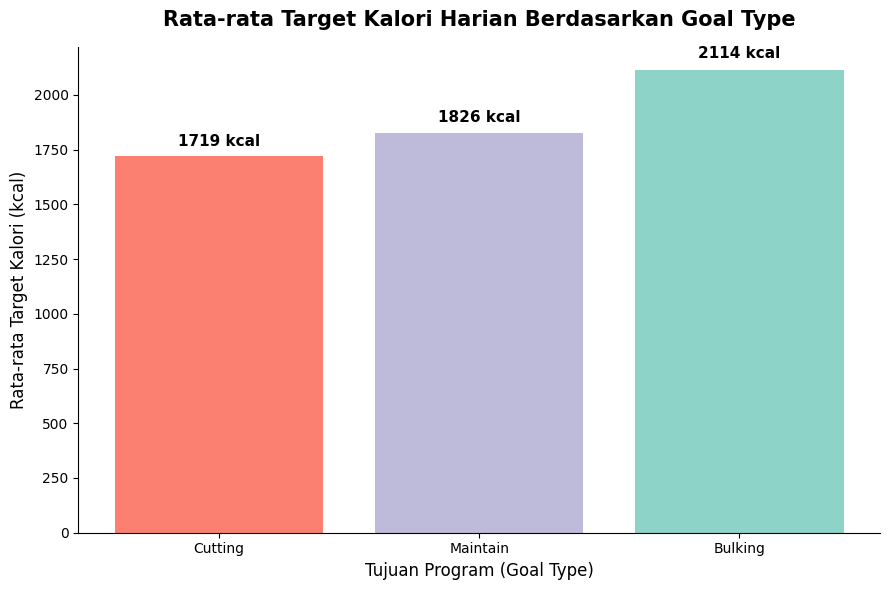

In [78]:

goal_analysis = (
    df.groupby('Goal_Type')['Target_Calorie_Day']
    .mean()
)

# Mengurutkan Kategori Goal (Kurus -> Normal -> Gemuk)
goal_order = ['Cutting', 'Maintain', 'Bulking']
goal_analysis = goal_analysis.reindex(goal_order)

print("Rata-rata Target Kalori berdasarkan Goal Type:")
display(goal_analysis)


my_colors_goal = ['#fb8072', '#bebada', '#8dd3c7'] # Merah salmon, Ungu pucat, Hijau tosca

plt.figure(figsize=(9, 6))

bars = plt.bar(goal_analysis.index, goal_analysis.values, color=my_colors_goal)

plt.title('Rata-rata Target Kalori Harian Berdasarkan Goal Type', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tujuan Program (Goal Type)', fontsize=12)
plt.ylabel('Rata-rata Target Kalori (kcal)', fontsize=12)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.0f} kcal',
             ha='center', va='bottom', fontsize=11, fontweight='bold')


sns.despine()

plt.tight_layout()
plt.show()

###Pertanyaan 3: Bagaimana pengaruh durasi program kesehatan terhadap perubahan target berat badan pengguna selama program berlangsung?

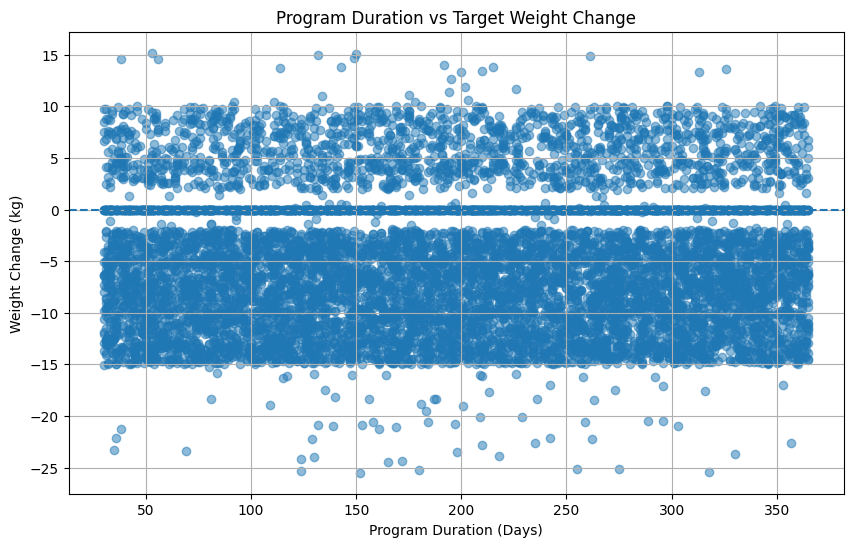

In [79]:


plt.figure(figsize=(10,6))

plt.scatter(
    df_clean['Program_Duration_Days'],
    df_clean['Weight_Change'],
    alpha=0.5
)

# Garis tengah
plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Program Duration vs Target Weight Change')

plt.xlabel('Program Duration (Days)')
plt.ylabel('Weight Change (kg)')

plt.grid(True)

plt.show()

###Insight:






**Pertanyaan 1**
- Fakta Data
  1. Durasi Tidur: Rata-rata waktu tidur semua kategori BMI ternyata sama persis, yaitu 7 jam.
  2. Tingkat Stres: Nilainya juga hampir sama (berkisar di skala 5). Namun, pengguna dengan berat badan Normal memiliki angka stres paling rendah (4.9), dan Underweight paling tinggi (5.1).
  3. Langkah Harian: Perbedaan paling jelas ada di sini. Pengguna Normal berjalan kaki paling banyak (sekitar 8180 langkah), sedangkan pengguna Obese (obesitas) paling sedikit bergerak (7947 langkah).

- Kesimpulan

  Pada data ini, durasi tidur dan tingkat stres pengguna secara keseluruhan sudah cukup seimbang dan tidak terlalu memengaruhi perbedaan berat badan. Faktor yang paling menentukan kategori BMI seseorang di sini adalah aktivitas fisik. Pengguna yang berat badannya ideal terbukti lebih rajin bergerak setiap harinya dibandingkan pengguna yang kelebihan berat badan.

- Saran

  Karena rata-rata tidur dan stres pengguna HabitSense sudah tergolong aman, aplikasi sebaiknya memfokuskan fitur utamanya pada pendorong aktivitas fisik. HabitSense bisa memberikan pengingat atau tantangan langkah harian yang bertahap khusus untuk pengguna Overweight dan Obese, agar mereka perlahan-lahan bisa mencapai tingkat keaktifan yang sama dengan pengguna Normal.

**Pertanyaan 2**
- Fakta Data

  Dari grafik terlihat jelas bahwa pengguna dengan tujuan berbeda memiliki target kalori yang berbeda. Pengguna yang ingin menurunkan berat badan (Cutting) memiliki target paling rendah, yaitu rata-rata 1719 kkal. Pengguna yang menjaga berat badan (Maintain) berada di tengah dengan 1826 kkal, sedangkan yang ingin menambah berat badan (Bulking) memiliki target paling tinggi sebesar 2114 kkal.

- Kesimpulan

  Sistem perhitungan kalori pada dataset ini sudah sangat logis dan sesuai dengan aturan dasar kesehatan. Sistem terbukti sudah benar dalam membatasi asupan kalori bagi pengguna yang ingin kurus, dan menambah asupan bagi pengguna yang ingin gemuk.

- Saran

  Karena perhitungan kalorinya sudah terbukti tepat dan akurat, HabitSense bisa menggunakan angka ini sebagai dasar fitur utama. Misalnya, aplikasi bisa otomatis merekomendasikan porsi atau menu makanan harian, serta memberikan notifikasi jika pengguna hampir melewati batas kalori mereka hari itu.

**Pertanyaan 3**
- Fakta Data
  1. **Kelompok Mayoritas Penurunan Berat Badan (Rentang -15 kg hingga -2 kg):** Kepadatan data paling tinggi dan berbentuk balok padat berada di area negatif, yang mewakili pengguna dengan program Cutting. Kelompok pengguna ini tersebar merata di seluruh durasi program, mulai dari jangka pendek (30 hari) hingga jangka panjang (365 hari) tanpa ada kecenderungan pola linier.
  2. **Kelompok Peningkatan Berat Badan (Rentang +2 kg hingga +10 kg):** Kepadatan data kedua berada di area positif, yang mewakili pengguna dengan program Bulking. Sama seperti kelompok sebelumnya, sebaran titik data meluas secara konstan dari durasi 30 hingga 365 hari.
  3. **Kelompok Target Tetap (Garis Padat di Angka 0):** Terlihat sebuah garis lurus yang sangat solid tepat di angka 0, menunjukkan kelompok pengguna Maintain yang juga berkomitmen pada berbagai variasi durasi program dari 1 bulan hingga 1 tahun.
  4. **Pencilan Data (Di luar batas -15 kg dan +10 kg):** Terdapat titik-titik data yang menyebar di area bawah (antara -15 kg hingga -25 kg) dan sedikit di area atas (di atas +10 kg). Pengguna di area ini memiliki target yang relatif lebih besar, namun tetap menentukan durasi waktu secara acak.

- Kesimpulan

  Durasi program kesehatan tidak memiliki pengaruh terhadap besaran target perubahan berat badan yang ditentukan pengguna. Baik pengguna yang memiliki target ringan maupun target yang cukup berat (-25 kg), mereka tetap menentukan jumlah hari program secara acak berdasarkan preferensi subjektif, bukan berdasarkan perhitungan logis atau pedoman standar kesehatan.

- Saran

  Fakta bahwa sebaran data berbentuk acak menunjukkan adanya kebutuhan panduan standar di dalam sistem. Pada formulir pendaftaran (Onboarding) website HabitSense, pengisian kolom durasi sebaiknya tidak dibiarkan kosong untuk diketik manual oleh pengguna. Website disarankan menerapkan Fitur Saran Durasi Otomatis (Smart Suggestion). Ketika pengguna memasukkan target berat badan, antarmuka website akan langsung menghitung dan mengunci rekomendasi durasi yang aman berdasarkan standar medis (misalnya pembatasan otomatis dengan prinsip penurunan atau kenaikan berat badan maksimal 0.5 kg hingga 1 kg per minggu).

In [80]:

df_clean.to_csv("habitsense_clean.csv", index=False)

from google.colab import files
files.download("habitsense_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Analisis Tambahan (Advanced)

## Feature Engineering

Membuat fitur perubahan berat badan

In [81]:
df['Weight_Change'] = (
    df['Target_Weight_kg'] - df['Weight_kg']
)

df[['Weight_kg', 'Target_Weight_kg', 'Weight_Change']].head()

,Weight_kg,Target_Weight_kg,Weight_Change
0,86.2,71.8,-14.4
1,63.6,56.2,-7.4
2,61.2,61.2,0.0
3,75.1,51.1,-24.0
4,74.5,66.8,-7.7


Membuat kategori aktivitas harian

In [82]:
def activity_level(steps):

    if steps < 5000:
        return 'Low Activity'

    elif steps < 10000:
        return 'Moderate Activity'

    else:
        return 'High Activity'

df['Activity_Level'] = df['Daily_Steps'].apply(activity_level)

df['Activity_Level'].value_counts()

,count
Activity_Level,
Moderate Activity,3727
High Activity,3545
Low Activity,2772


Membuat kategori kualitas tidur

In [83]:
def sleep_quality(hours):

    if hours < 6:
        return 'Poor Sleep'

    elif hours <= 8:
        return 'Normal Sleep'

    else:
        return 'Excellent Sleep'

df['Sleep_Quality'] = df['Sleep_Duration'].apply(sleep_quality)

df['Sleep_Quality'].value_counts()

,count
Sleep_Quality,
Normal Sleep,6301
Poor Sleep,1882
Excellent Sleep,1861


Membuat rasio kalori terhadap durasi program

In [84]:
df['Calories_Per_Day'] = (
    df['Target_Calorie_Day'] /
    df['Program_Duration_Days']
)

df[['Target_Calorie_Day',
    'Program_Duration_Days',
    'Calories_Per_Day']].head()

,Target_Calorie_Day,Program_Duration_Days,Calories_Per_Day
0,1749.0,204.0,8.573529
1,1201.0,39.0,30.794872
2,1952.0,279.0,6.996416
3,1188.0,130.0,9.138462
4,1927.0,228.0,8.451754


Membuat kategori perubahan berat badan

In [85]:
def weight_goal(change):

    if change < -0:
        return 'Weight Loss'

    elif change <= 0:
        return 'Weight Gain'

    else:
        return 'Maintain'

df['Weight_Goal_Category'] = (
    df['Weight_Change'].apply(weight_goal)
)

df['Weight_Goal_Category'].value_counts()

,count
Weight_Goal_Category,
Weight Loss,6888
Maintain,1737
Weight Gain,1419


**Insight**

1. Fitur baru `Weight_Change` berhasil dibuat untuk menghitung selisih antara berat badan target dan berat badan awal pengguna, sehingga mempermudah analisis tujuan program kesehatan apakah pengguna ingin menurunkan, menaikkan, atau mempertahankan berat badan.

2. Pembuatan fitur `Activity_Level` membantu mengelompokkan pengguna berdasarkan jumlah langkah harian menjadi kategori aktivitas rendah, sedang, dan tinggi, sehingga pola aktivitas fisik pengguna dapat dianalisis dengan lebih mudah.

3. Fitur `Sleep_Quality` digunakan untuk mengklasifikasikan kualitas tidur pengguna berdasarkan durasi tidur, sehingga hubungan antara kualitas tidur, tingkat stres, dan kondisi BMI dapat dianalisis secara lebih terstruktur.

4. Fitur `Calories_Per_Day` berhasil memberikan gambaran mengenai intensitas kebutuhan kalori pengguna selama program kesehatan berlangsung dengan membandingkan target kalori terhadap durasi program.

5. Fitur `Weight_Goal_Category` membantu mengidentifikasi tujuan utama pengguna dalam program kesehatan, seperti weight loss, weight gain, atau maintain, sehingga segmentasi pengguna menjadi lebih jelas.

6. Proses feature engineering membuat dataset menjadi lebih informatif dan kaya fitur dibanding dataset awal karena variabel baru mampu merepresentasikan pola perilaku kesehatan pengguna secara lebih spesifik.

7. Fitur-fitur baru yang dihasilkan dapat meningkatkan kualitas exploratory data analysis, visualisasi data, hingga performa model machine learning karena data menjadi lebih mudah diinterpretasikan dan memiliki representasi informasi yang lebih kuat.

8. Dengan adanya feature engineering, sistem HabitSense dapat lebih mudah dikembangkan menjadi platform rekomendasi kesehatan personalisasi berdasarkan aktivitas fisik, pola tidur, target berat badan, dan kebutuhan kalori pengguna.

## A/B Testing

Membuat kelompok A dan B

In [86]:
group_A = df[
    df['Goal_Type'] == 'Bulking'
]['Target_Calorie_Day']

group_B = df[
    df['Goal_Type'] == 'Cutting'
]['Target_Calorie_Day']

Melihat rata-rata tiap kelompok

In [87]:
print("Rata-rata Bulking :", group_A.mean())
print("Rata-rata Cutting :", group_B.mean())

Rata-rata Bulking : 2113.768789808917
Rata-rata Cutting : 1718.79036644718


Melakukan independent T-Test

In [88]:
t_stat, p_value = ttest_ind(
    group_A,
    group_B,
    equal_var=False
)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : 42.599541030081724
P-Value : 2.806533464282403e-298


Interpretasi Hasil

In [89]:
alpha = 0.05

if p_value < alpha:
    print("Terdapat perbedaan signifikan antara kedua kelompok")
else:
    print("Tidak terdapat perbedaan signifikan antara kedua kelompok")

Terdapat perbedaan signifikan antara kedua kelompok


Visualisasi A/B Testing

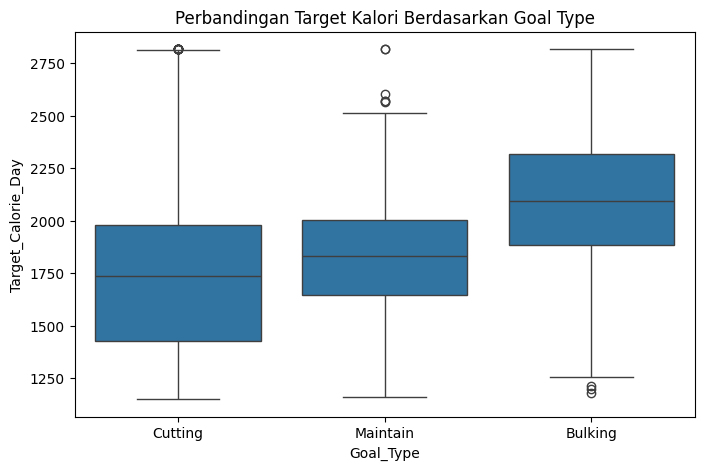

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Goal_Type',
    y='Target_Calorie_Day'
)

plt.title('Perbandingan Target Kalori Berdasarkan Goal Type')
plt.show()

**Insight**

1. Pengguna dengan goal type Bulking cenderung memiliki target kalori harian lebih tinggi dibanding pengguna dengan goal type Cutting.
2. Hasil independent t-test digunakan untuk mengetahui apakah perbedaan rata-rata target kalori tersebut signifikan secara statistik atau hanya terjadi secara kebetulan.
3. Jika nilai p-value lebih kecil dari 0.05, maka dapat disimpulkan bahwa terdapat perbedaan signifikan antara kebutuhan kalori pengguna Bulking dan Cutting.
4. Analisis ini membantu memahami bahwa kebutuhan nutrisi pengguna dipengaruhi oleh tujuan kesehatan yang berbeda.
5. Hasil A/B testing dapat digunakan sebagai dasar pengembangan sistem rekomendasi kalori yang lebih personal pada platform HabitSense.